# View result of asteroids data set
Written by Kiyoaki Okudaira<br>
*Kyushu University Hanada Lab / University of Washington / IAU CPS SatHub<br>
(okudaira.kiyoaki.528@s.kyushu-u.ac.jp or kiyoaki@uw.edu)<br>
<br>
View result of the processing of asteroids data set from NASA SENTRY / ESA AEGIS API.<br>
<br>
**History**<br>
coding 2026-02-04 : 1st coding<br>
update 2026-02-10 : Add IP distribution and event date plot<br>
update 2026-02-13 : Add velocity infinity<br>
<br>
This code is written for University of Washington ASTR 302 WINTER 2026 Project NEO.<br>
(c) 2026 Kiyoaki Okudaira - Kyushu University Hanada Lab (SSDL) / University of Washington / IAU CPS SatHub

### Import and initial settings
**PATH settings**

In [1]:
base_PATH = "/Users/kiyoaki/VScode/projectneo-2026/"
output_PATH = base_PATH + "data"

**Standard libraries**

In [2]:
import pickle
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import QTable, vstack, join
from matplotlib.lines import Line2D

### NASA SENTRY vs ESA AEGIS Comparison Dataset
**Import dataset**

In [3]:
with open(f'{output_PATH}/workspace_NASA_ESA_ip_table.pkl', "rb") as f:
    NASA_ESA_ip_table = pickle.load(f)
NASA_ESA_ip_table

des_chr,des_num,event_id,ip_NASA,ip_ESA,v_inf_NASA,v_inf_ESA,v_inf
str9,object,str20,object,object,object,object,float64
1950DA,29075,1950DA_2880-03-16,0.000377,None,14.1,None,14.1
1979XB,None,1979XB_2056-12-12,1.915e-07,2.34e-07,23.7606234552547,25.17,23.7606234552547
1979XB,None,1979XB_2065-12-16,None,2.72e-09,None,25.17,25.17
1979XB,None,1979XB_2086-12-16,1.067e-07,None,23.7606234552547,None,23.7606234552547
1979XB,None,1979XB_2101-12-14,None,3.46e-09,None,25.17,25.17
1979XB,None,1979XB_2102-12-16,1.158e-10,None,23.7606234552547,None,23.7606234552547
1979XB,None,1979XB_2113-12-14,5.532e-07,4.94e-07,23.7606234552547,25.17,23.7606234552547
1991BA,None,1991BA_2026-01-17,None,2.55e-09,None,16.49,16.49
1991BA,None,1991BA_2027-01-19,2.107e-09,3.45e-09,16.7227981196217,16.49,16.7227981196217


**Difference of IP**<br>
If only one of the 2 data set lists an event, the ip_agreements will be `none`

In [4]:
ip_differences = []
ip_agreements = []
ip_relations = []
years = []
for row in NASA_ESA_ip_table:
    if row["ip_NASA"] is None:
        ip_differences.append(-row["ip_ESA"])
        ip_agreements.append(None)
        ip_relations.append(float('inf'))
    elif row["ip_ESA"] is None:
        ip_differences.append(row["ip_NASA"])
        ip_agreements.append(None)
        ip_relations.append(float('inf'))
    elif row["ip_NASA"] is None and row["ip_ESA"] is None:
        raise ValueError("Invalid event : both IPs are None")
    else:
        ip_differences.append(row["ip_NASA"] - row["ip_ESA"])
        ip_agreements.append(False)
        if row["ip_NASA"] > row["ip_ESA"]:
            ip_relations.append(row["ip_NASA"]/row["ip_ESA"])
        else:
            ip_relations.append(row["ip_ESA"]/row["ip_NASA"])
    years.append(int(row["event_id"][-10:-6]))
NASA_ESA_ip_table["year"] = years
NASA_ESA_ip_table["ip_difference"] = ip_differences
NASA_ESA_ip_table["ip_agreement"] = ip_agreements
NASA_ESA_ip_table["ip_relation"] = ip_relations

NASA_ESA_ip_table

des_chr,des_num,event_id,ip_NASA,ip_ESA,v_inf_NASA,v_inf_ESA,v_inf,year,ip_difference,ip_agreement,ip_relation
str9,object,str20,object,object,object,object,float64,int64,float64,object,float64
1950DA,29075,1950DA_2880-03-16,0.000377,None,14.1,None,14.1,2880,0.000377,None,inf
1979XB,None,1979XB_2056-12-12,1.915e-07,2.34e-07,23.7606234552547,25.17,23.7606234552547,2056,-4.2500000000000017e-08,False,1.2219321148825066
1979XB,None,1979XB_2065-12-16,None,2.72e-09,None,25.17,25.17,2065,-2.72e-09,None,inf
1979XB,None,1979XB_2086-12-16,1.067e-07,None,23.7606234552547,None,23.7606234552547,2086,1.067e-07,None,inf
1979XB,None,1979XB_2101-12-14,None,3.46e-09,None,25.17,25.17,2101,-3.46e-09,None,inf
1979XB,None,1979XB_2102-12-16,1.158e-10,None,23.7606234552547,None,23.7606234552547,2102,1.158e-10,None,inf
1979XB,None,1979XB_2113-12-14,5.532e-07,4.94e-07,23.7606234552547,25.17,23.7606234552547,2113,5.92e-08,False,1.119838056680162
1991BA,None,1991BA_2026-01-17,None,2.55e-09,None,16.49,16.49,2026,-2.55e-09,None,inf
1991BA,None,1991BA_2027-01-19,2.107e-09,3.45e-09,16.7227981196217,16.49,16.7227981196217,2027,-1.343e-09,False,1.6373991457047936


### Plot result
**IP difference histogram**

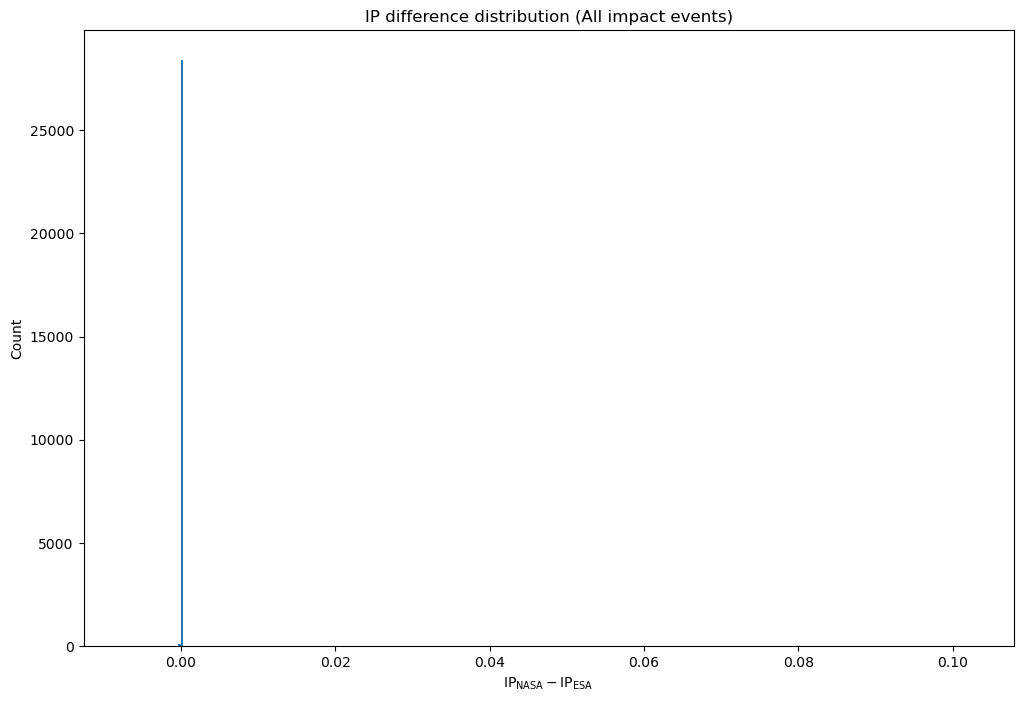

In [5]:
plt.figure(figsize = (12, 8))
_ = plt.hist(NASA_ESA_ip_table["ip_difference"], bins="auto")
# _ = plt.hist(NASA_ESA_ip_table[(NASA_ESA_ip_table["ip_agreement"] != None)]["ip_difference"], bins="auto")
plt.xlabel(r"$\mathrm{IP_{NASA}}-\mathrm{IP_{ESA}}$")
plt.ylabel("Count")
plt.title("IP difference distribution (All impact events)")
plt.show()

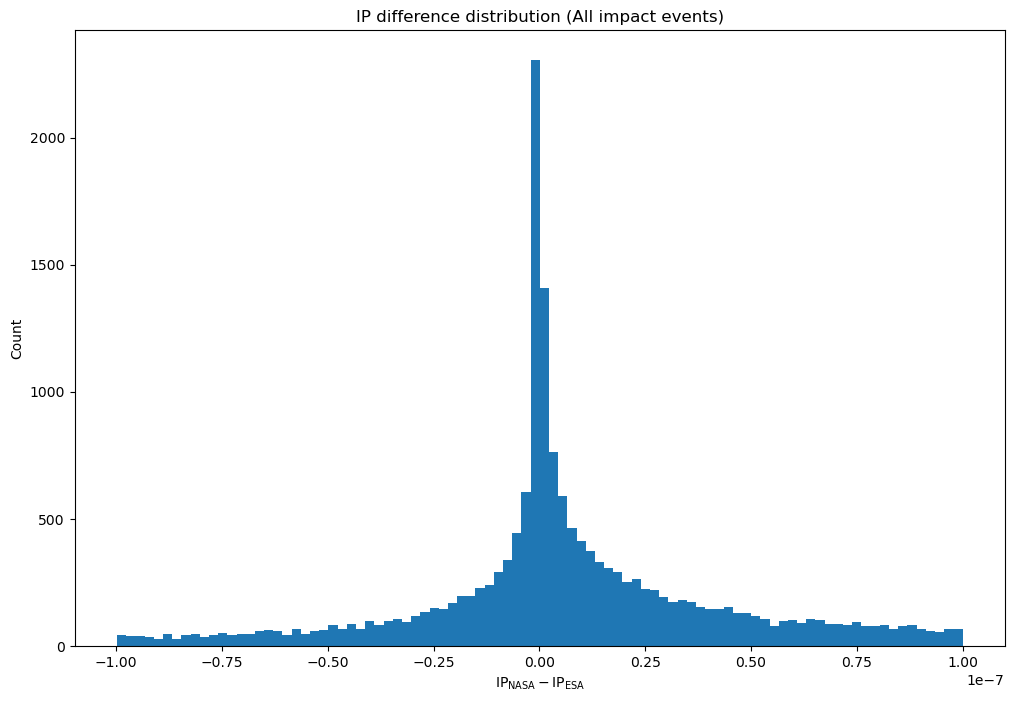

In [6]:
plt.figure(figsize = (12, 8))
_ = plt.hist(NASA_ESA_ip_table[(abs(NASA_ESA_ip_table["ip_difference"]) < 0.0000001)]["ip_difference"], bins="auto")
# _ = plt.hist(NASA_ESA_ip_table[(abs(NASA_ESA_ip_table["ip_difference"]) < 0.0000001) & (NASA_ESA_ip_table["ip_agreement"] != None)]["ip_difference"], bins="auto")
plt.xlabel(r"$\mathrm{IP_{NASA}}-\mathrm{IP_{ESA}}$")
plt.ylabel("Count")
plt.title("IP difference distribution (All impact events)")
plt.show()

**IP ratio histogram**

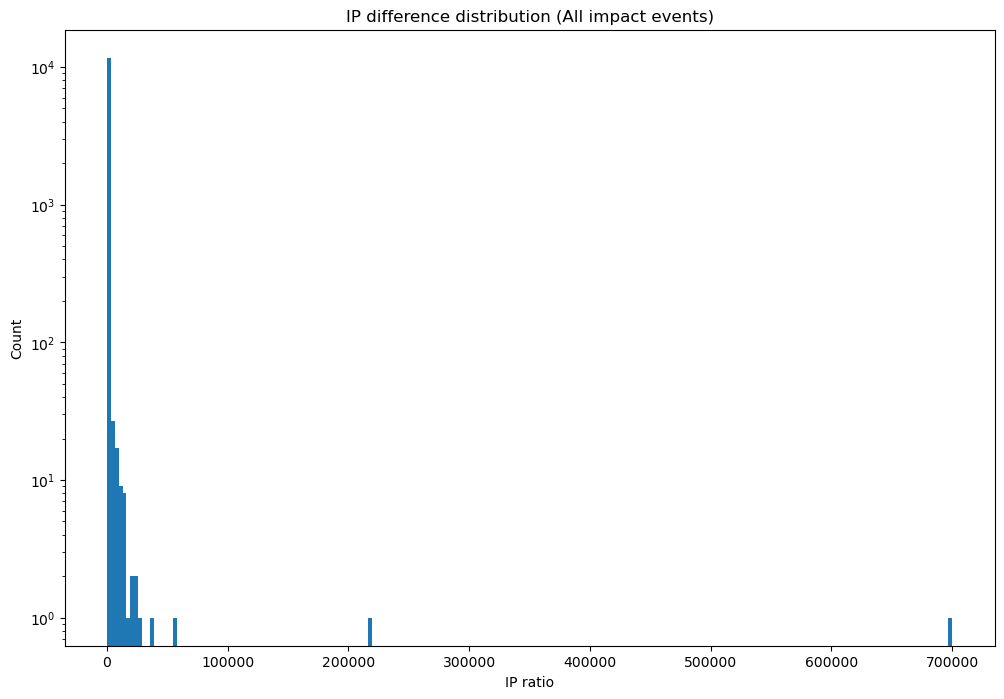

In [7]:
plt.figure(figsize = (12, 8))
# _ = plt.hist(NASA_ESA_ip_table["ip_relation"], bins="auto")
_ = plt.hist(NASA_ESA_ip_table[(NASA_ESA_ip_table["ip_agreement"] != None)]["ip_relation"], bins="auto")
plt.xlabel("IP ratio")
plt.ylabel("Count")
plt.yscale("log")
plt.title("IP difference distribution (All impact events)")
plt.show()

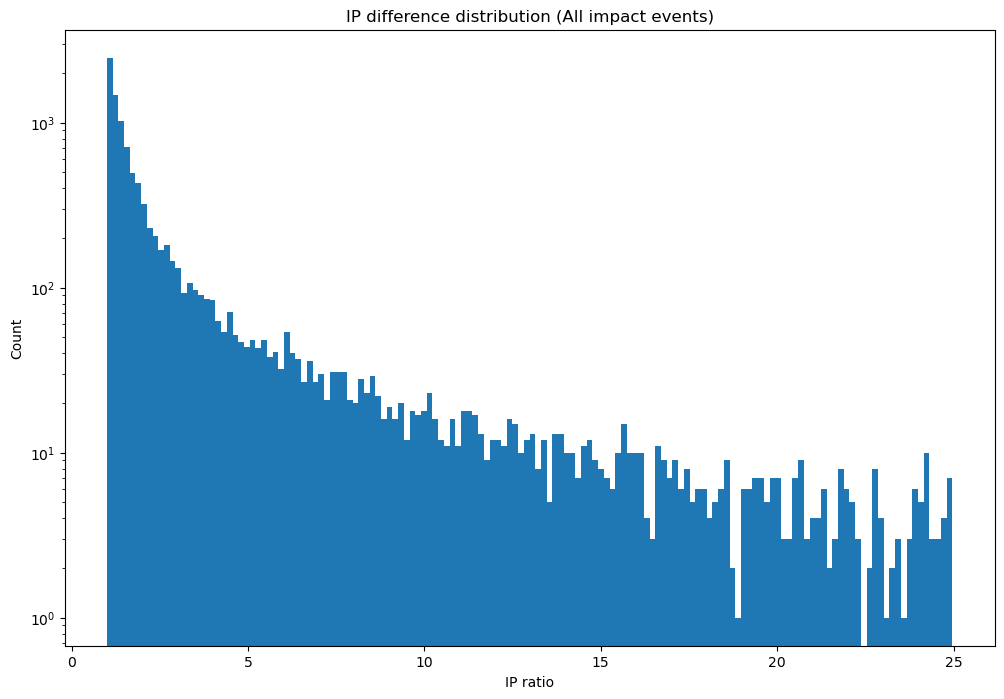

In [8]:
plt.figure(figsize = (12, 8))
# _ = plt.hist(NASA_ESA_ip_table["ip_relation"], bins="auto")
_ = plt.hist(NASA_ESA_ip_table[(NASA_ESA_ip_table["ip_agreement"] != None) & (NASA_ESA_ip_table["ip_relation"] < 25)]["ip_relation"], bins="auto")
plt.xlabel("IP ratio")
plt.ylabel("Count")
plt.yscale("log")
plt.title("IP difference distribution (All impact events)")
plt.show()

**IP distribution histogram**

In [9]:
NASA_ip_list = [0 if f is None else f for f in NASA_ESA_ip_table["ip_NASA"]]
ESA_ip_list = [0 if f is None else f for f in NASA_ESA_ip_table["ip_ESA"]]

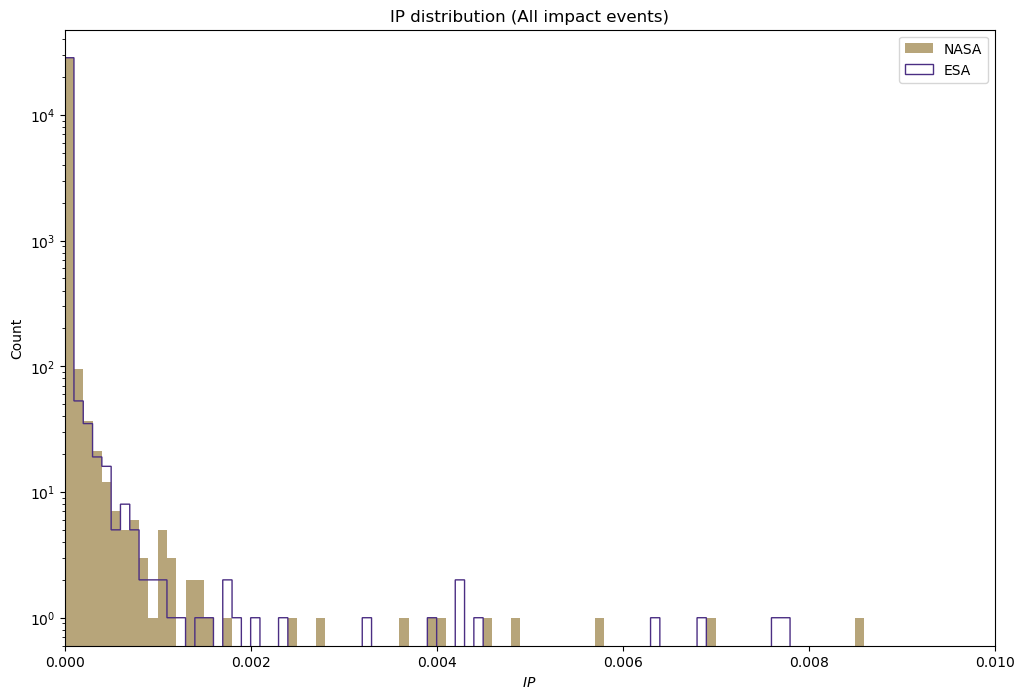

In [10]:
plt.figure(figsize = (12, 8))
_ = plt.hist(NASA_ip_list, bins=1000, range=(0, 0.1), color="#b7a57a", label = "NASA")
_ = plt.hist(ESA_ip_list, bins=1000, range=(0, 0.1), color="#4b2e83", histtype='step', linewidth=1, label = "ESA")
plt.xlim((0,0.01))
# plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"${IP}$")
plt.ylabel("Count")
plt.title("IP distribution (All impact events)")
plt.legend()
plt.show()

**IP difference vs Event date**

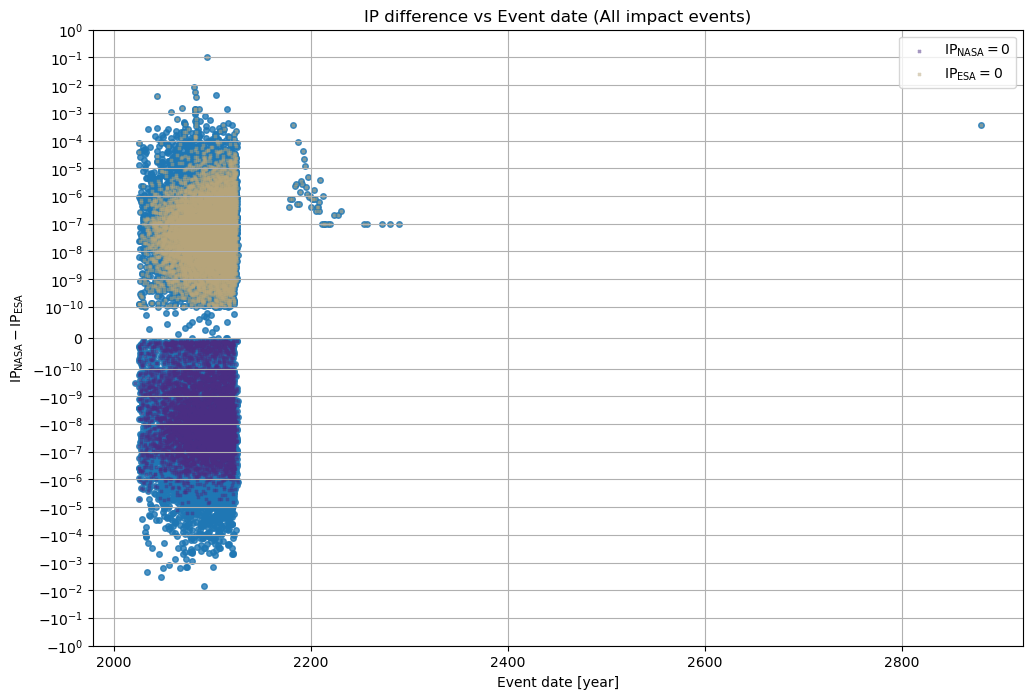

In [11]:
NASA_zero_mask = (NASA_ESA_ip_table["ip_NASA"] == None)
ESA_zero_mask = (NASA_ESA_ip_table["ip_ESA"] == None)


plt.figure(figsize=(12, 8))

plt.scatter(
    NASA_ESA_ip_table["year"],
    NASA_ESA_ip_table["ip_difference"],
    s=16,
    alpha=0.8
)

plt.scatter(
    NASA_ESA_ip_table[NASA_zero_mask]["year"],
    NASA_ESA_ip_table[NASA_zero_mask]["ip_difference"],
    color="#4b2e83",
    marker="x",
    s=4,
    alpha=0.5,
    label=r"$\mathrm{IP_{NASA}} = 0$"
)

plt.scatter(
    NASA_ESA_ip_table[ESA_zero_mask]["year"],
    NASA_ESA_ip_table[ESA_zero_mask]["ip_difference"],
    color="#b7a57a",
    marker="x",
    s=4,
    alpha=0.5,
    label=r"$\mathrm{IP_{ESA}} = 0$"
)

plt.xlabel("Event date [year]")
plt.ylabel(r"$\mathrm{IP_{NASA}}-\mathrm{IP_{ESA}}$")
plt.title("IP difference vs Event date (All impact events)")

plt.ylim(-1, 1)
plt.yscale("symlog", linthresh=1e-10)
plt.grid(True, which="both")
plt.legend()

plt.show()

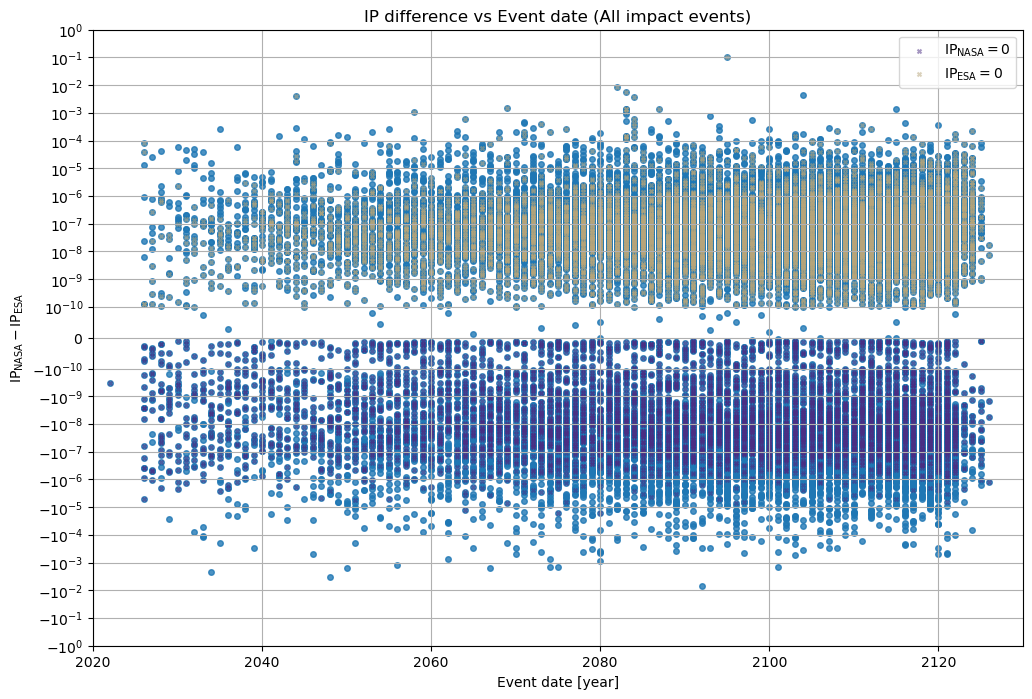

In [12]:
plt.figure(figsize=(12, 8))

plt.scatter(
    NASA_ESA_ip_table["year"],
    NASA_ESA_ip_table["ip_difference"],
    s=16,
    alpha=0.8
)

plt.scatter(
    NASA_ESA_ip_table[NASA_zero_mask]["year"],
    NASA_ESA_ip_table[NASA_zero_mask]["ip_difference"],
    color="#4b2e83",
    marker="x",
    s=8,
    alpha=0.5,
    label=r"$\mathrm{IP_{NASA}} = 0$"
)

plt.scatter(
    NASA_ESA_ip_table[ESA_zero_mask]["year"],
    NASA_ESA_ip_table[ESA_zero_mask]["ip_difference"],
    color="#b7a57a",
    marker="x",
    s=8,
    alpha=0.5,
    label=r"$\mathrm{IP_{ESA}} = 0$"
)

plt.xlabel("Event date [year]")
plt.ylabel(r"$\mathrm{IP_{NASA}}-\mathrm{IP_{ESA}}$")
plt.title("IP difference vs Event date (All impact events)")

plt.xlim(2020, 2130)
plt.ylim(-1, 1)
plt.yscale("symlog", linthresh=1e-10)
plt.grid(True, which="both")
plt.legend()

plt.show()

**IP difference vs Velocity infinity**

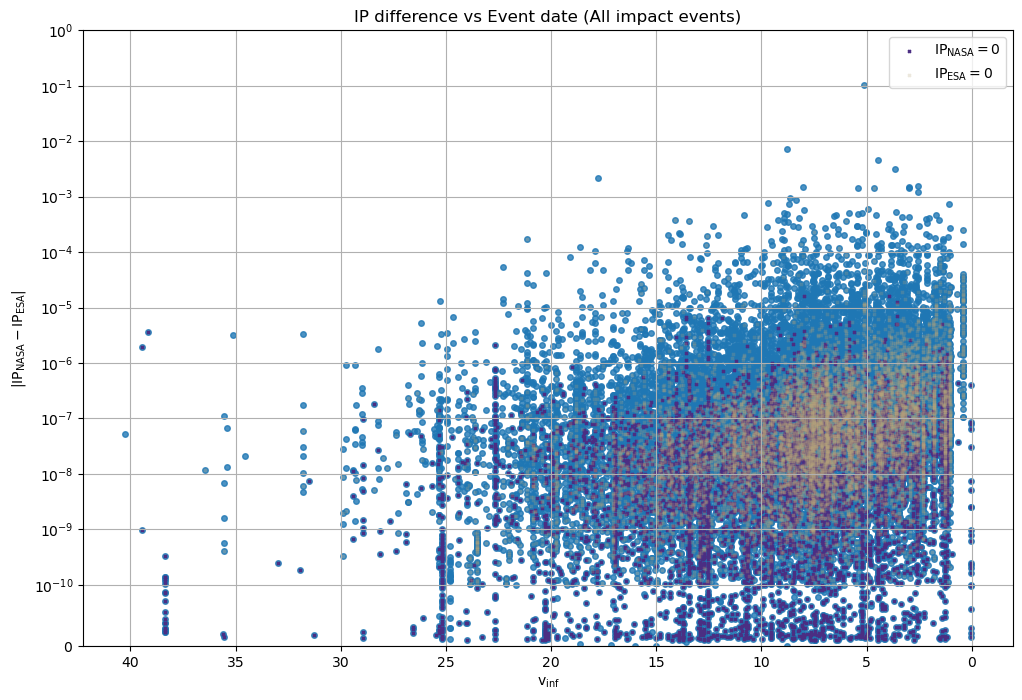

In [13]:
NASA_zero_mask = (NASA_ESA_ip_table["ip_NASA"] == None)
ESA_zero_mask = (NASA_ESA_ip_table["ip_ESA"] == None)

plt.figure(figsize=(12, 8))

plt.scatter(
    NASA_ESA_ip_table["v_inf"],
    abs(NASA_ESA_ip_table["ip_difference"]),
    s=16,
    alpha=0.8
)

plt.scatter(
    NASA_ESA_ip_table[NASA_zero_mask]["v_inf"],
    abs(NASA_ESA_ip_table[NASA_zero_mask]["ip_difference"]),
    color="#4b2e83",
    marker="x",
    s=4,
    # alpha=0.5,
    label=r"$\mathrm{IP_{NASA}} = 0$"
)

plt.scatter(
    NASA_ESA_ip_table[ESA_zero_mask]["v_inf"],
    abs(NASA_ESA_ip_table[ESA_zero_mask]["ip_difference"]),
    color="#b7a57a",
    marker="x",
    s=4,
    alpha=0.25,
    label=r"$\mathrm{IP_{ESA}} = 0$"
)

plt.xlabel(r"$\mathrm{v_{inf}}$")
plt.ylabel(r"$|\mathrm{IP_{NASA}}-\mathrm{IP_{ESA}}|$")
plt.title("IP difference vs Event date (All impact events)")

plt.gca().invert_xaxis()
plt.ylim(0, 1)
plt.yscale("symlog", linthresh=1e-10)
plt.grid(True, which="both")
plt.legend()

plt.show()

**IP ratio vs Event date**

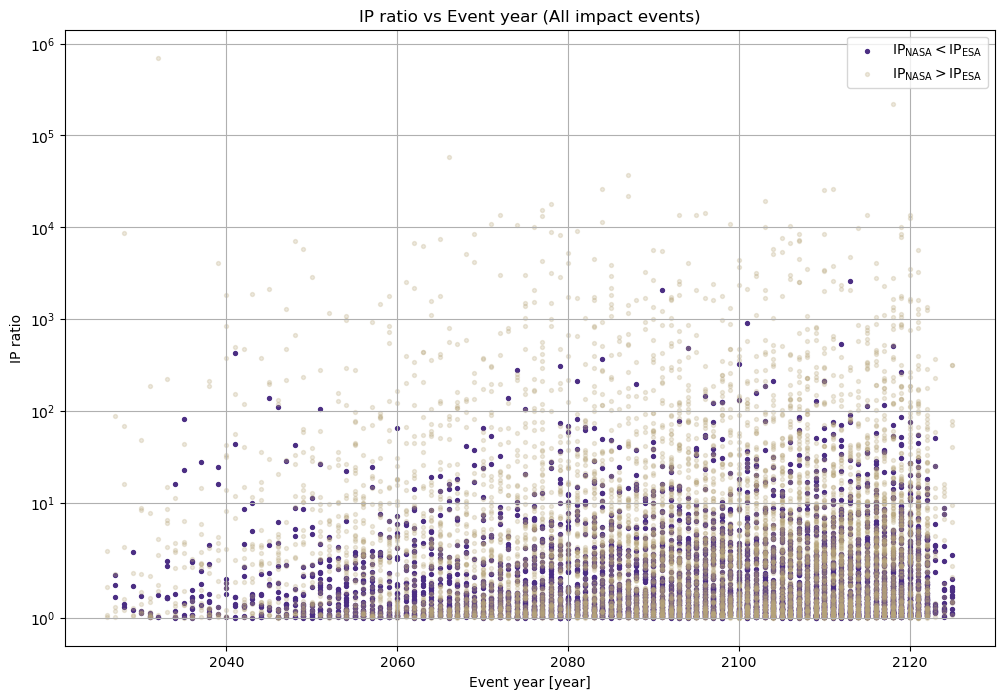

In [22]:
NASA_zero_mask = (NASA_ESA_ip_table["ip_NASA"] == None)
ESA_zero_mask = (NASA_ESA_ip_table["ip_ESA"] == None)

NASA_mask = NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["ip_NASA"] > NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["ip_ESA"]
ESA_mask = NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["ip_NASA"] < NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["ip_ESA"]

plt.figure(figsize=(12, 8))

# plt.scatter(
#     NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["year"],
#     abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["ip_relation"]),
#     s=16,
#     alpha=0.8
# )

plt.scatter(
    NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][ESA_mask]["year"],
    abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][ESA_mask]["ip_relation"],),
    color="#4b2e83",
    # marker="x",
    s=8,
    # alpha=0.5,
    label=r"$\mathrm{IP_{NASA}} < \mathrm{IP_{ESA}}$"
)

plt.scatter(
    NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][NASA_mask]["year"],
    abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][NASA_mask]["ip_relation"],),
    color="#b7a57a",
    # marker="x",
    s=8,
    alpha=0.25,
    label=r"$\mathrm{IP_{NASA}} > \mathrm{IP_{ESA}}$"
)

plt.xlabel("Event year [year]")
plt.ylabel("IP ratio")
plt.title("IP ratio vs Event year (All impact events)")

plt.yscale("symlog")
plt.grid(True, which="both")
plt.legend()

plt.show()

**IP ratio vs Velocity infinity**

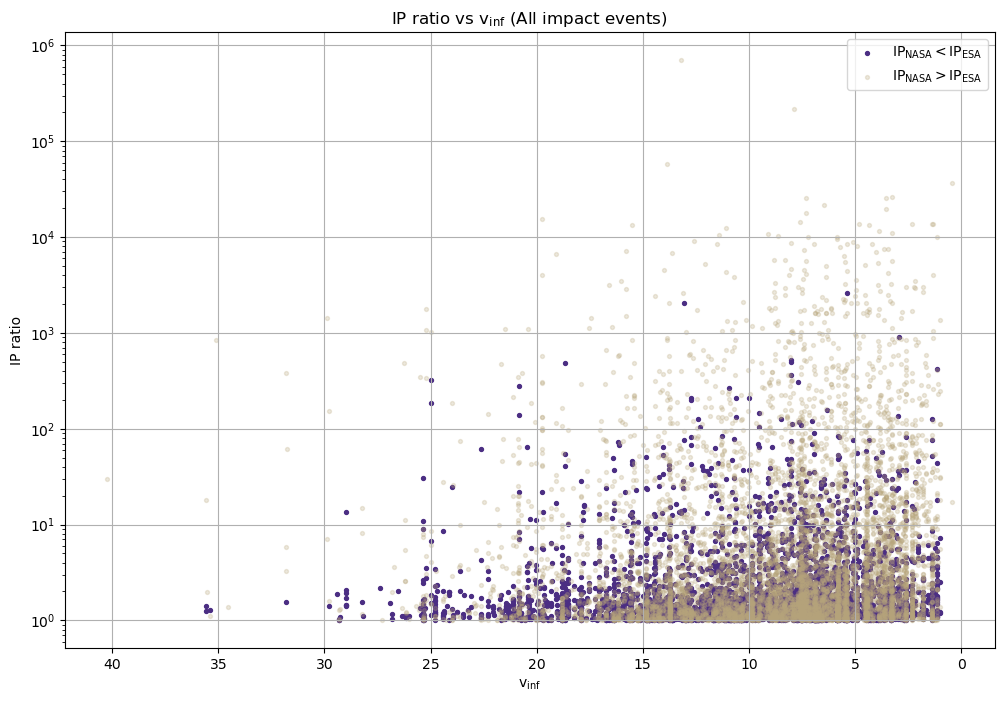

In [21]:
NASA_zero_mask = (NASA_ESA_ip_table["ip_NASA"] == None)
ESA_zero_mask = (NASA_ESA_ip_table["ip_ESA"] == None)

plt.figure(figsize=(12, 8))

# plt.scatter(
#     NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["v_inf"],
#     abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask]["ip_relation"]),
#     s=16,
#     alpha=0.8
# )

plt.scatter(
    NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][ESA_mask]["v_inf"],
    abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][ESA_mask]["ip_relation"],),
    color="#4b2e83",
    # marker="x",
    s=8,
    # alpha=1,
    label=r"$\mathrm{IP_{NASA}} < \mathrm{IP_{ESA}}$"
)

plt.scatter(
    NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][NASA_mask]["v_inf"],
    abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][NASA_mask]["ip_relation"],),
    color="#b7a57a",
    # marker="x",
    s=8,
    alpha=0.25,
    label=r"$\mathrm{IP_{NASA}} > \mathrm{IP_{ESA}}$"
)

plt.xlabel(r"$\mathrm{v_{inf}}$")
plt.ylabel("IP ratio")
plt.title(r"IP ratio vs $\mathrm{v_{inf}}$ (All impact events)")

plt.gca().invert_xaxis()
plt.yscale("log")
plt.grid(True)
plt.legend()

plt.show()

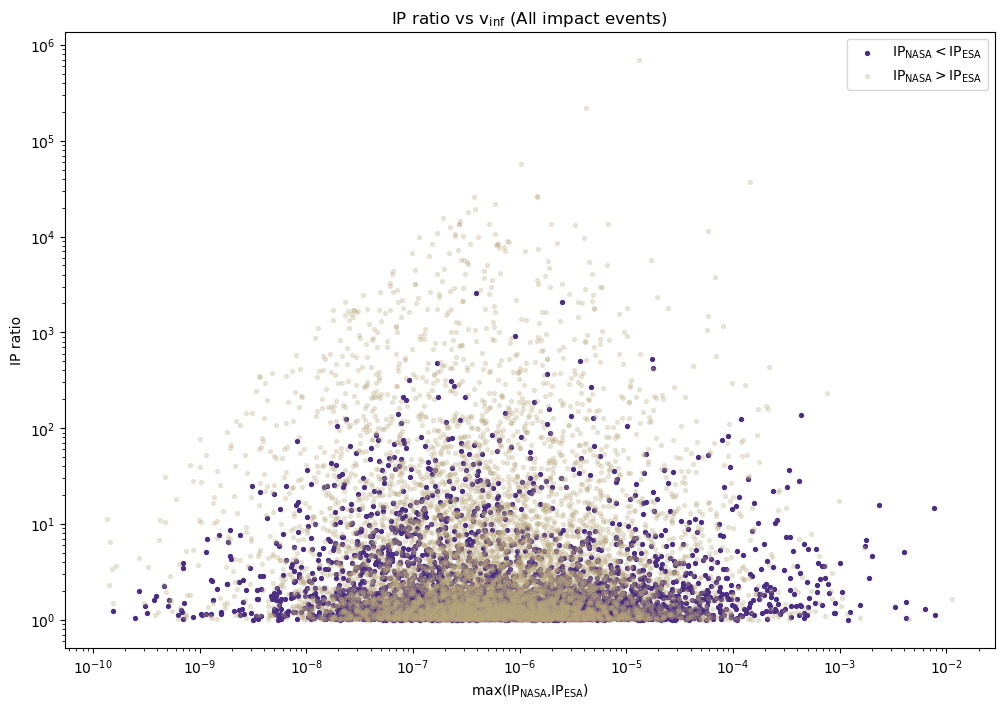

In [16]:
ip_MAX = []

for row in NASA_ESA_ip_table:
    if row["ip_NASA"] is None:
        ip_MAX.append(row["ip_ESA"])
        # pass
    elif row["ip_ESA"] is None:
        ip_MAX.append(row["ip_NASA"])
        # pass
    else:
        ip_MAX.append(max(row["ip_NASA"],row["ip_ESA"]))

ip_MAX = np.array(ip_MAX)

plt.figure(figsize=(12, 8))

# plt.scatter(
#     ip_MAX,
#     abs(NASA_ESA_ip_table["ip_relation"]),
#     s=16,
#     alpha=0.8
# )

plt.scatter(
    ip_MAX[~NASA_zero_mask & ~ESA_zero_mask][ESA_mask],
    abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][ESA_mask]["ip_relation"],),
    color="#4b2e83",
    # marker="x",
    s=8,
    # alpha=0.5,
    label=r"$\mathrm{IP_{NASA}} < \mathrm{IP_{ESA}}$"
)

plt.scatter(
    ip_MAX[~NASA_zero_mask & ~ESA_zero_mask][NASA_mask],
    abs(NASA_ESA_ip_table[~NASA_zero_mask & ~ESA_zero_mask][NASA_mask]["ip_relation"],),
    color="#b7a57a",
    # marker="x",
    s=8,
    alpha=0.25,
    label=r"$\mathrm{IP_{NASA}} > \mathrm{IP_{ESA}}$"
)

plt.xlabel(r"max($\mathrm{IP_{NASA}}$,$\mathrm{IP_{ESA}}$)")
plt.ylabel("IP ratio")
plt.title(r"IP ratio vs $\mathrm{v_{inf}}$ (All impact events)")

plt.xscale("log")
plt.yscale("log")
# plt.grid(True, which="both")
plt.legend()

plt.show()

**IP by NASA vs IP by ESA for each event**<br>
Scatter plot of the IP by NASA vs the IP by ESA

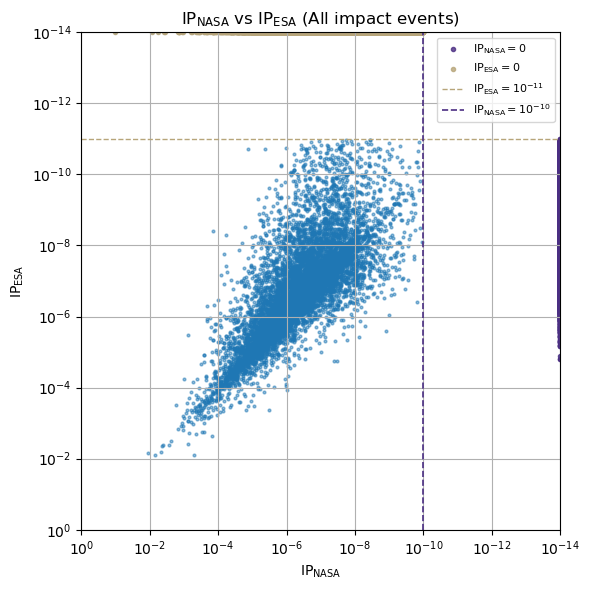

In [17]:
eps = 1e-14

x_raw = np.array([0 if x is None else x for x in NASA_ESA_ip_table["ip_NASA"]], dtype=float)
y_raw = np.array([0 if x is None else x for x in NASA_ESA_ip_table["ip_ESA"]], dtype=float)

x_plot = np.where(x_raw <= 0, eps, x_raw)
y_plot = np.where(y_raw <= 0, eps, y_raw)
x_zero_mask = (x_raw <= 0)
y_zero_mask = (y_raw <= 0)

plt.figure(figsize=(6,6))
plt.scatter(x_plot, y_plot, s=4, alpha=0.5)
plt.scatter(
    x_plot[x_zero_mask],
    y_plot[x_zero_mask],
    marker=".",
    color="#4b2e83",
    alpha=0.8,
    # s=8,
    label=r"$\mathrm{IP_{NASA}} = 0$"
)
plt.scatter(
    x_plot[y_zero_mask],
    y_plot[y_zero_mask],
    marker=".",
    color="#b7a57a",
    alpha=0.8,
    # s=8,
    label=r"$\mathrm{IP_{ESA}} = 0$"
)

plt.axhline(
    y=1e-11,
    color="#b7a57a",
    linestyle="--",
    linewidth=1,
    label=r"$\mathrm{IP_{ESA}} = 10^{-11}$"
)

plt.axvline(
    x=1e-10,
    color="#4b2e83",
    linestyle="--",
    linewidth=1.2,
    label=r"$\mathrm{IP_{NASA}} = 10^{-10}$"
)

plt.xlabel(r"$\mathrm{IP_{NASA}}$")
plt.ylabel(r"$\mathrm{IP_{ESA}}$")
plt.title(r"$\mathrm{IP_{NASA}}$ vs $\mathrm{IP_{ESA}}$ (All impact events)")

plt.xscale("log")
plt.yscale("log")

plt.xlim(1, eps)
plt.ylim(1, eps)

plt.grid()
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**IP agreement**<br>
Plots the agreement between NASA and ESA Impact Probabilities

In [18]:
def ip_agreement(nasa_shared_ips, esa_shared_ips, threshold_order=1.0):
    """
    Plots the agreement between NASA and ESA Impact Probabilities.
    Finds the threshold using a 95th percentile bin.
    """
    nasa = np.array(nasa_shared_ips, dtype=float)
    esa = np.array(esa_shared_ips, dtype=float)

    # Filter out 0 or NaN values
    valid = (nasa > 0) & (esa > 0) & np.isfinite(nasa) & np.isfinite(esa)
    nasa_clean = nasa[valid]
    esa_clean = esa[valid]

    # Mean
    x_geom_mean = np.sqrt(nasa_clean * esa_clean)

    # Log Difference
    y_log_diff = np.abs(np.log10(nasa_clean) - np.log10(esa_clean))

    # Color
    dot_colors = np.where(nasa_clean > esa_clean, 'gold', 'navy')

    # Binning for the 95th Percentile
    bins = np.logspace(np.log10(np.min(x_geom_mean)), np.log10(np.max(x_geom_mean)), 15)
    bin_centers = np.sqrt(bins[:-1] * bins[1:]) # Center of each bin for plotting
    
    perc_95 = np.zeros_like(bin_centers)
    
    for i in range(len(bins)-1):
        mask = (x_geom_mean >= bins[i]) & (x_geom_mean < bins[i+1])
        if np.sum(mask) > 0:
            perc_95[i] = np.percentile(y_log_diff[mask], 95)
        else:
            perc_95[i] = np.nan

    # Find the threshold
    divergence_ip = []
    
    print(len(bin_centers))
    for i in range(0,len(bin_centers)-1):
        y2 = perc_95[i]      
        y1 = perc_95[i+1]  
        
        if np.isnan(y1) or np.isnan(y2):
            continue
            
        if y1 <= threshold_order and y2 > threshold_order:
            x1 = np.log10(bin_centers[i+1])
            x2 = np.log10(bin_centers[i])
            
            slope = (y2 - y1) / (x2 - x1)
            x_thresh = x1 + (threshold_order - y1) / slope
            
            divergence_ip.append(10**x_thresh)
            break
    
    divergence_ip = divergence_ip[-1]

    # Plot
    plt.figure(figsize=(10, 7))
    ax = plt.gca()

    plt.scatter(x_geom_mean, y_log_diff, alpha=0.5, s=15, color=dot_colors, label='Asteroid IPs')

    plt.plot(bin_centers, perc_95, alpha=0.4, color='green', linewidth=2.5, marker='o', 
             label='95th Percentile')

    plt.axhline(threshold_order, color='red', linestyle='--', linewidth=1.5)
    
    if divergence_ip:
        plt.axvline(divergence_ip, alpha=0.5, color='purple', linestyle='-', linewidth=2)

    plt.xscale('log')
    ax.invert_xaxis() 

    plt.xlabel('Impact Probability (Mean)')
    plt.ylabel(r'Impact Probability Ratio ($\Delta y$ in Orders of Mag)')
    plt.title('NASA vs ESA Impact Probability Agreement (All impact events)')
    
    plt.grid(True, which="both", ls="--", alpha=0.3)
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='NASA IP > ESA IP', markerfacecolor='gold', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='ESA IP > NASA IP', markerfacecolor='navy', markersize=8),
        Line2D([0], [0], color='green', lw=2.5, marker='o', label='95th Percentile'),
        Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=f'Threshold ({threshold_order} Order of Mag)'),
        Line2D([0], [0], color='purple', lw=1.5, linestyle='-', label=f'Divergence Point ({divergence_ip:.1e})')
    ]
    plt.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show();

14


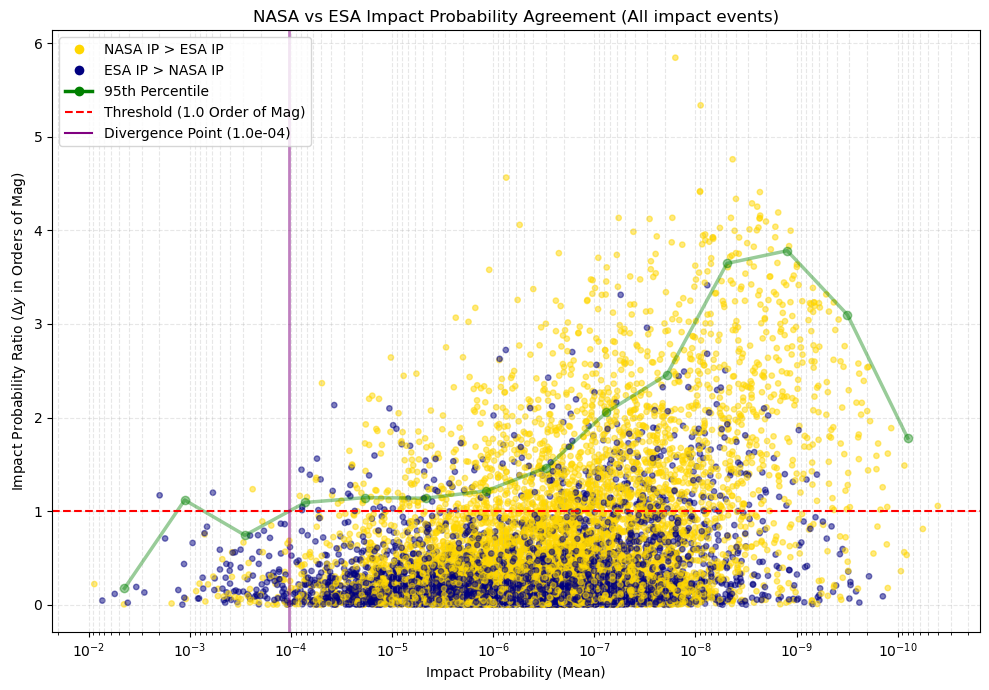

In [19]:
ip_agreement(NASA_ESA_ip_table["ip_NASA"], NASA_ESA_ip_table["ip_ESA"])